In [20]:
import os
import synth_reader as sr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from astropy.io import fits
from astropy.table import Table



In [2]:
home = '/home/holman/StarLightv05/outputs/prefit/'
list_files = os.listdir(home)
list_files.sort()

print(len(list_files),' DONE!')


sr.FITS_conversion(id = list_files[15],home = home)

for e in list_files:
    sr.FITS_conversion(id = e,home = home)

582  DONE!
Fits file already in /home/holman/StarLightv05/outputs/prefit/002.GD3.MILES45.fits
Fits file already in /home/holman/StarLightv05/outputs/prefit/001.CAL.MILES45.fits
Fits file already in /home/holman/StarLightv05/outputs/prefit/001.CAL.MILES45.fits
Fits file already in /home/holman/StarLightv05/outputs/prefit/001.GD1.MILES45.fits
Fits file already in /home/holman/StarLightv05/outputs/prefit/001.GD1.MILES45.fits
Fits file already in /home/holman/StarLightv05/outputs/prefit/001.GD2.MILES45.fits
Fits file already in /home/holman/StarLightv05/outputs/prefit/001.GD2.MILES45.fits
Fits file already in /home/holman/StarLightv05/outputs/prefit/001.GD3.MILES45.fits
Fits file already in /home/holman/StarLightv05/outputs/prefit/001.GD3.MILES45.fits
Fits file already in /home/holman/StarLightv05/outputs/prefit/002.CAL.MILES45.fits
Fits file already in /home/holman/StarLightv05/outputs/prefit/002.CAL.MILES45.fits
Fits file already in /home/holman/StarLightv05/outputs/prefit/002.GD1.MILES4

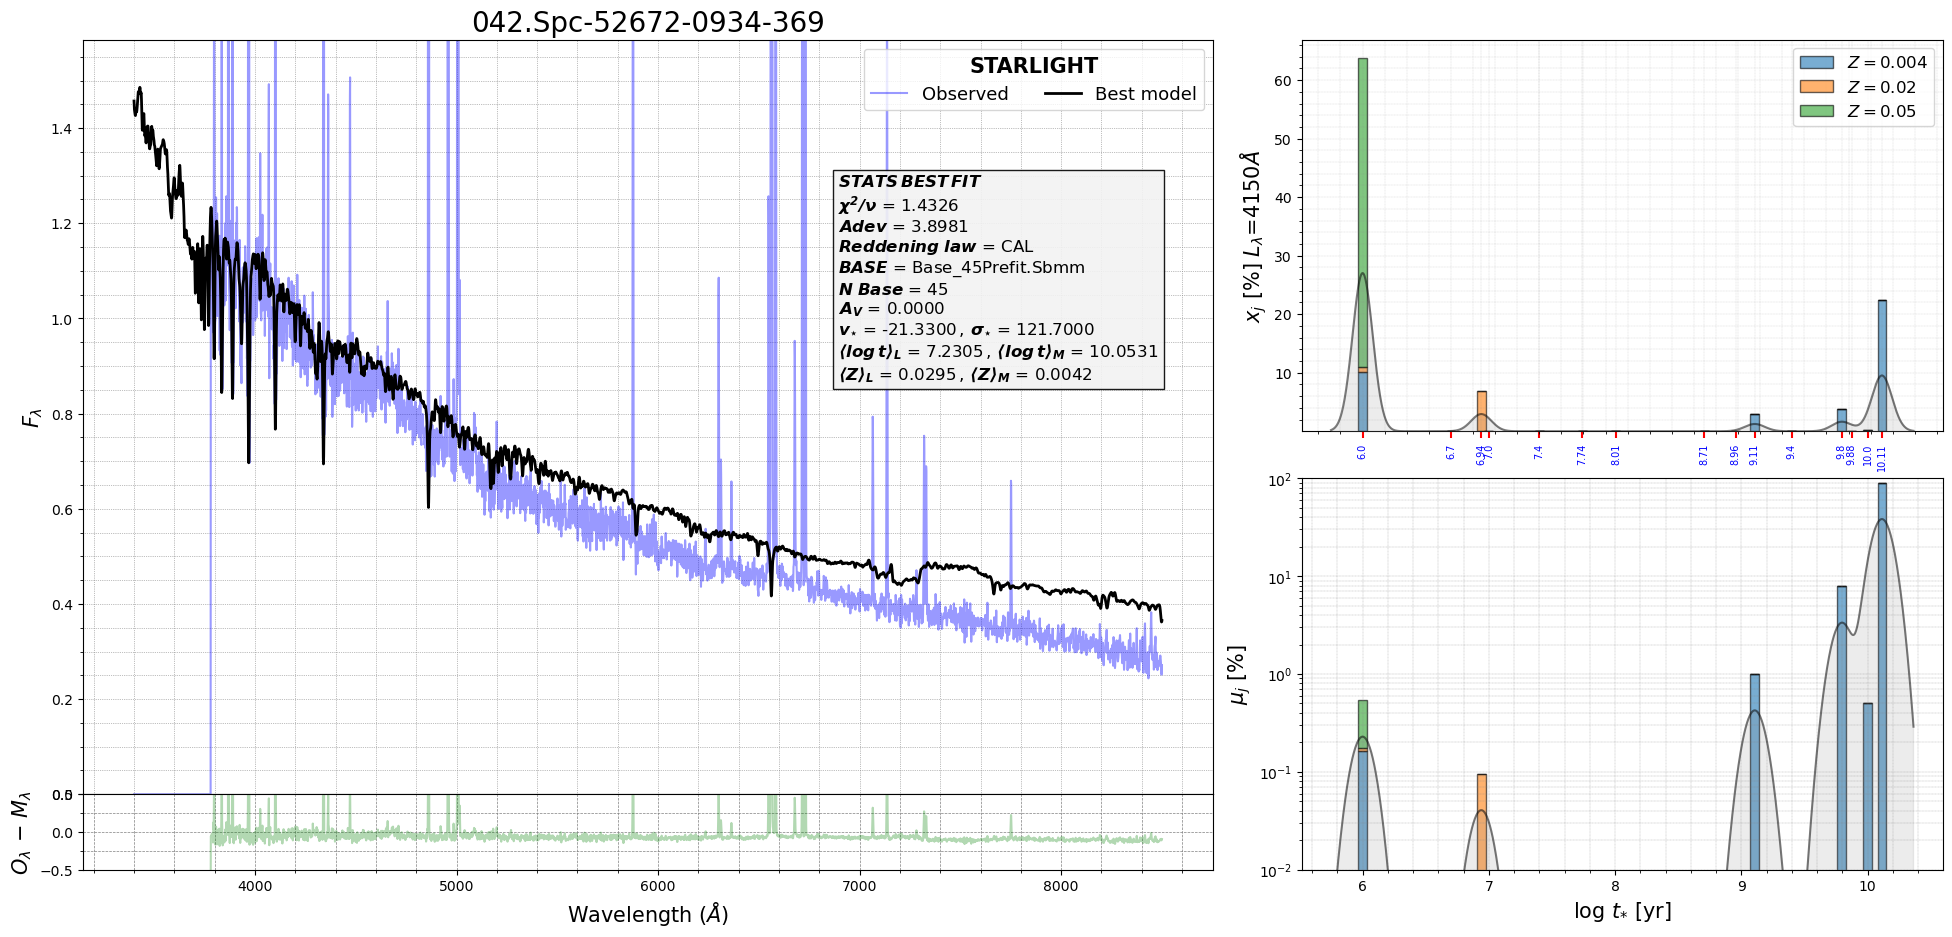

In [19]:
sr.spec_pop_STAR_mod(id = '042.CAL.MILES45.fits',
            home = '/home/holman/StarLightv05/outputs/prefit/')

# El numero 56 seria el perfecto para probar el fitter de las lineas y creacion de mascaras.

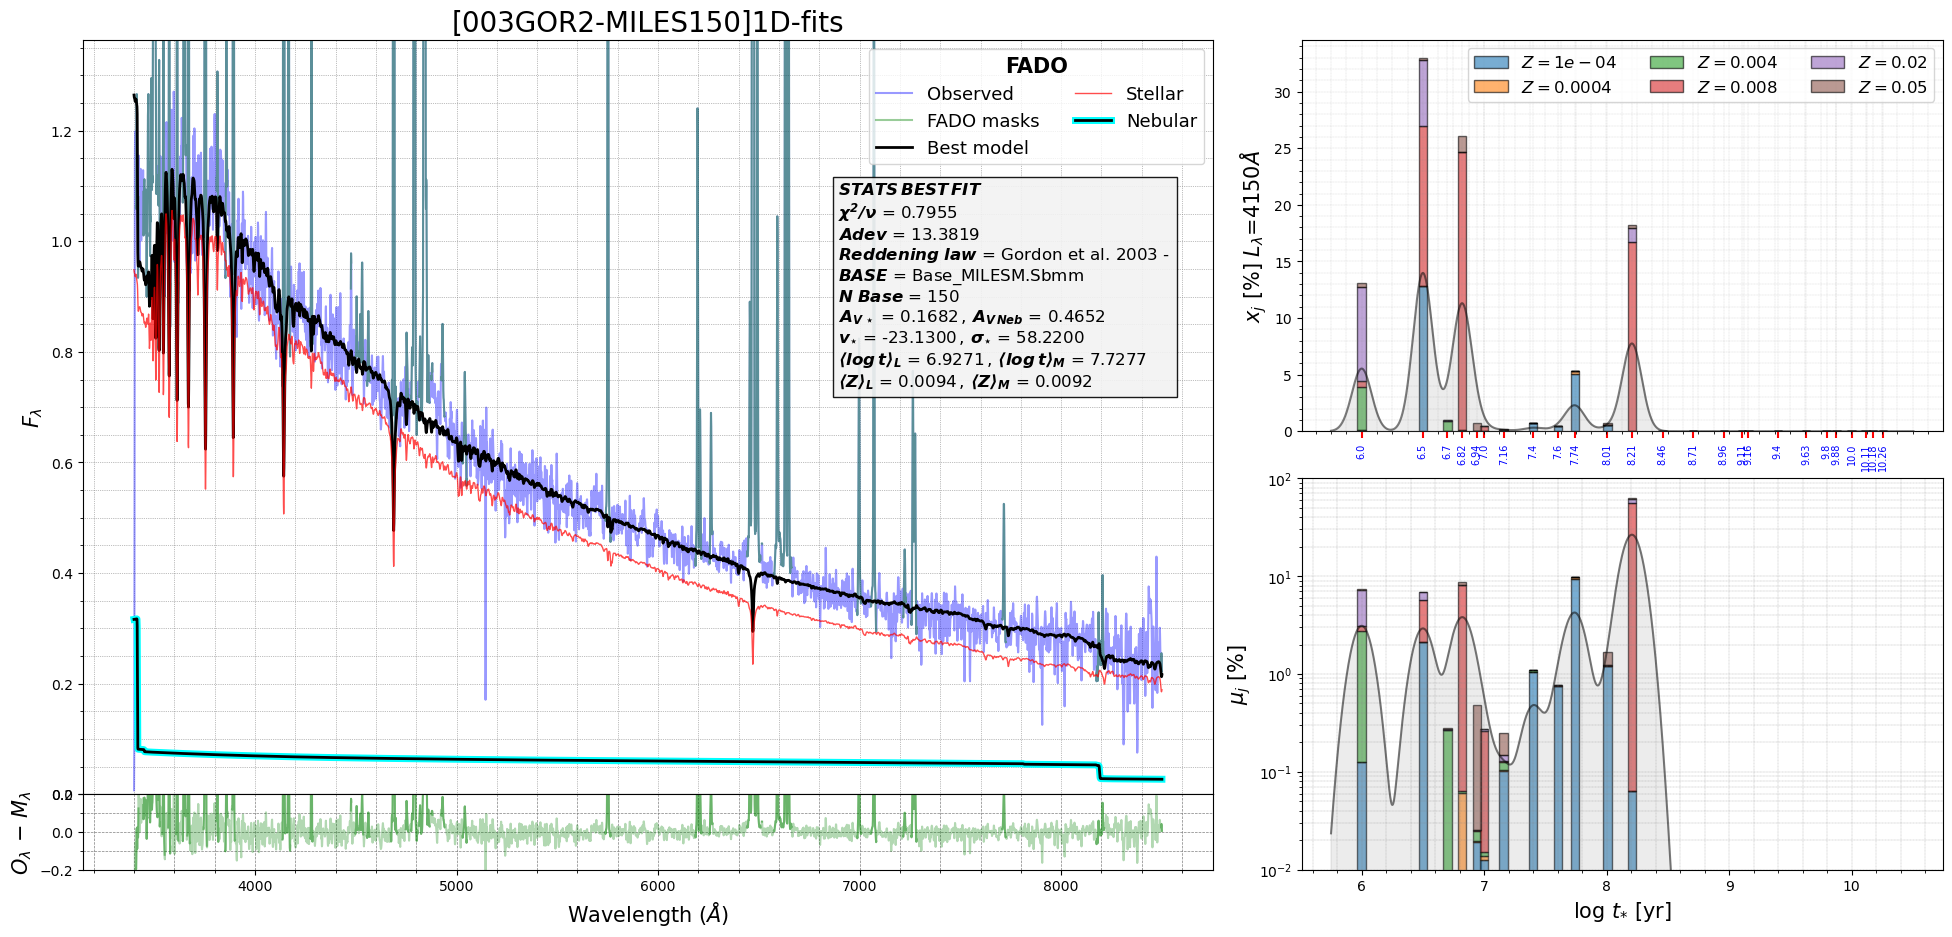

In [44]:
sr.spec_pop_FADO_mod(id = '003GOR2.MILES150_1D.fits',
            home = '/home/holman/FADOv1b/o_FR4150/')

In [34]:
sr.FADO_merit_reader(id = '077CALR.MILES150_1D.fits',
            home = '/home/holman/FADOv1b/o_FR4150/')

[1.373, 18.605203215608892]

In [8]:
def merit_stats(path,title):
    spec_xxxx = [f for f in os.listdir(path) if f.endswith('_1D.fits')]
    spec_xxxx.sort()

    chi_cal,adev_cal = [],[]
    chi_gd1,adev_gd1 = [],[]
    chi_gd2,adev_gd2 = [],[]
    chi_gd3,adev_gd3 = [],[]

    for i in spec_xxxx:
        merits_ = sr.FADO_merit_reader(id = i,home = path)
        if 'CALR' in i:
            chi_cal.append(merits_[0])
            adev_cal.append(merits_[1])
        if 'GOR1' in i:
            chi_gd1.append(merits_[0])
            adev_gd1.append(merits_[1])
        if 'GOR2' in i:
            chi_gd2.append(merits_[0])
            adev_gd2.append(merits_[1])
        if 'GOR3' in i:
            chi_gd3.append(merits_[0])
            adev_gd3.append(merits_[1])

    merits = [chi_cal,chi_gd1,chi_gd2,chi_gd3,adev_cal,adev_gd1,adev_gd2,adev_gd3]
    nombres_columnas = [r'$\chi^2$',r'$\chi^2$',r'$\chi^2$',r'$\chi^2$',r'Adev',r'Adev',r'Adev',r'Adev']
    ext_laws = ['Calzetti','Gordon1','Gordon2','Gordon3','Calzetti','Gordon1','Gordon2','Gordon3']
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8), sharey=False)
    fig.suptitle(title, fontsize=20, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        ax.hist(merits[i], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
        data_stats = [np.mean(merits[i]),np.median(merits[i]),np.max(merits[i]),np.min(merits[i])]
        ax.axvline(data_stats[0], color='r', linestyle='dashed', linewidth=2, label=f'Mean: {data_stats[0]:.2f}')
        ax.axvline(data_stats[1], color='g', linestyle='dashed', linewidth=2, label=f'Median: {data_stats[1]:.2f}')
        ax.axvline(data_stats[2], color='b', linestyle='dashed', linewidth=2, label=f'Max: {data_stats[2]:.2f}')
        ax.axvline(data_stats[3], color='c', linestyle='dashed', linewidth=2, label=f'Min: {data_stats[3]:.2f}')
        ax.set_title(ext_laws[i])
        col_idx = i # % 4
        ax.set_xlabel(nombres_columnas[col_idx], fontsize=12, color='darkred')
        ax.legend()
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

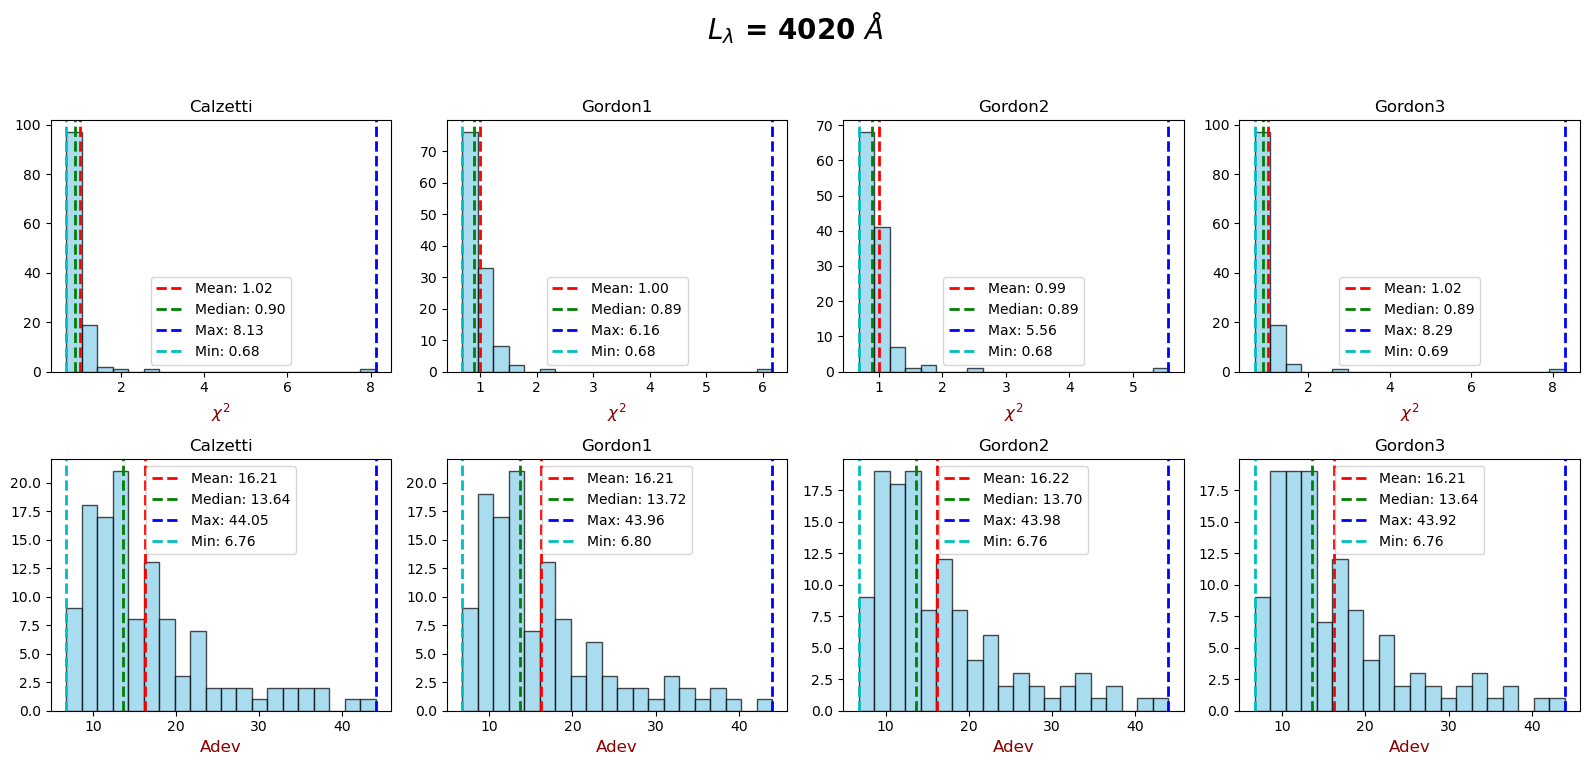

In [9]:
merit_stats(path ='/home/holman/FADOv1b/o_FR4020/',
            title=r'$L_{\lambda}$ = 4020 $\AA$')

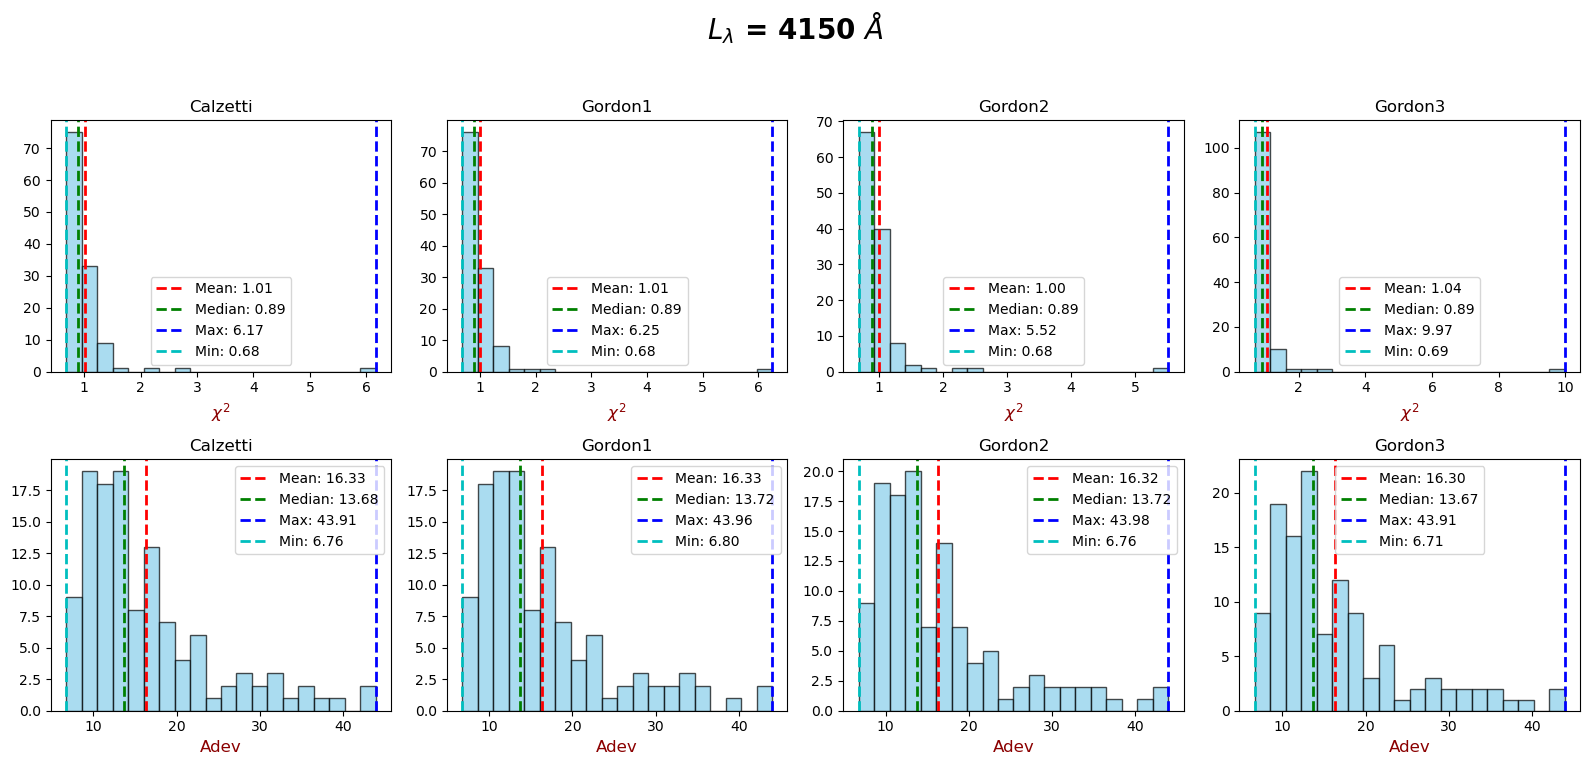

In [10]:
merit_stats(path ='/home/holman/FADOv1b/o_FR4150/',
            title=r'$L_{\lambda}$ = 4150 $\AA$')

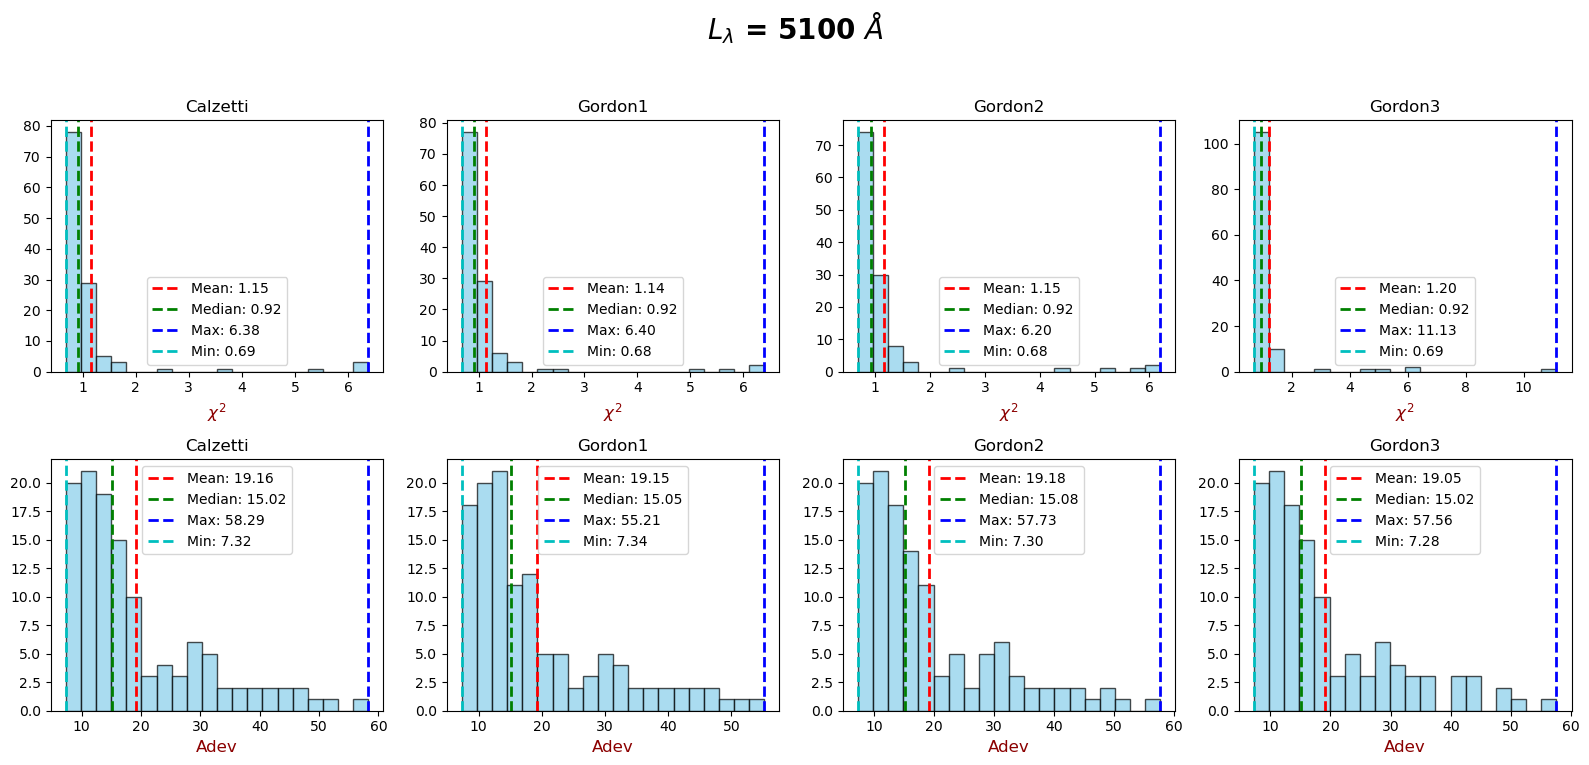

In [11]:
merit_stats(path ='/home/holman/FADOv1b/o_FR5100/',
            title=r'$L_{\lambda}$ = 5100 $\AA$')

In [27]:
storage_dir = os.path.join(os.path.expanduser("~"),'Data_storageHII/')
os.makedirs(storage_dir, exist_ok=True)
tex_folder = storage_dir + '/specTx_Tab5ID/'
tex_list = os.listdir(tex_folder)
#tex_list.remove('DOWNspec_listDR7.txt')
tex_list = sorted(tex_list)
len(tex_list)

121

In [28]:
lambda_range = np.arange(3400,8901,1)
fx_sum = []

for i in range(len(tex_list)):
    Df = pd.read_csv(tex_folder+tex_list[i], header=None, names=['lambda','Fx'], sep='\s+')
    for u in range(len(lambda_range)):
        tmp_df = Df[Df['lambda']==lambda_range[u]]
        if len(tmp_df) == 1:
            if i == 0:
                fx_sum.append(tmp_df['Fx'].iloc[0])
            else:
                fx_sum[u] = fx_sum[u] + tmp_df['Fx'].iloc[0]
        else:
            if i == 0:
                fx_sum.append(0)
            else:
                fx_sum[u] = fx_sum[u] + 0
        del tmp_df
    del Df
    #print(f'Added data from {tex_list[i]}')

    

In [29]:
len(fx_sum)

5501

[4150, 4125, 4175]

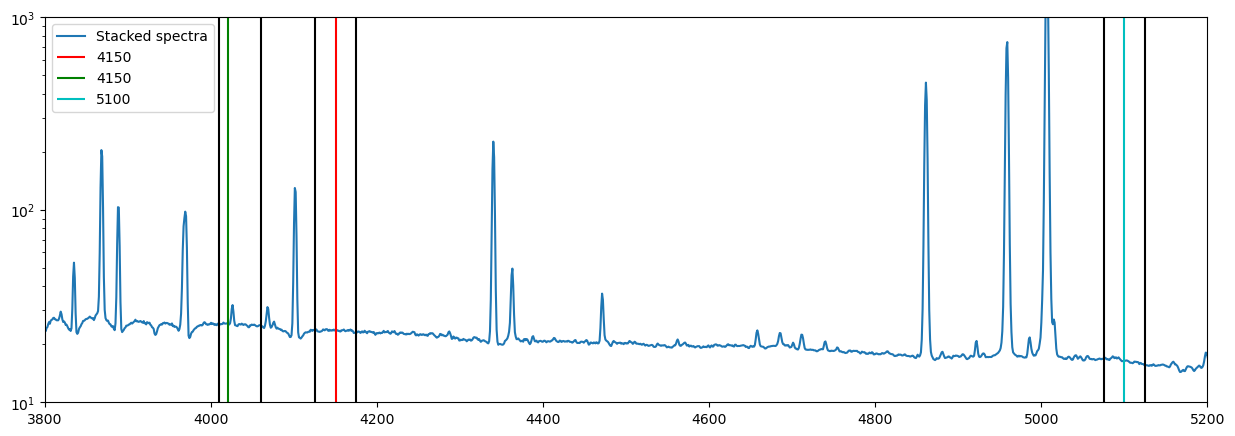

In [42]:
fig,ax = plt.subplots(figsize=(15, 5)) 

fx_ave = np.array(fx_sum) / 121
ax.plot(lambda_range,fx_ave,label = 'Stacked spectra')
ax.set_yscale('log')
ax.set_ylim([10e1,1e2])
ax.set_xlim([3800,5200])

l_norm = 4150

l_norms = [l_norm,l_norm-25,l_norm+25]

ax.vlines(l_norms[0],np.min(fx_ave),np.max(fx_ave),color = 'r',label = '4150')
ax.vlines(l_norms[1],np.min(fx_ave),np.max(fx_ave),color = 'k')
ax.vlines(l_norms[2],np.min(fx_ave),np.max(fx_ave),color = 'k')

ax.vlines(4020,np.min(fx_ave),np.max(fx_ave),color = 'g',label = '4150')
ax.vlines(4010,np.min(fx_ave),np.max(fx_ave),color = 'k')
ax.vlines(4060,np.min(fx_ave),np.max(fx_ave),color = 'k')


ax.vlines(5100,np.min(fx_ave),np.max(fx_ave),color = 'c',label = '5100')
ax.vlines(5075,np.min(fx_ave),np.max(fx_ave),color = 'k')
ax.vlines(5125,np.min(fx_ave),np.max(fx_ave),color = 'k')


#ax.vlines(4570,np.min(fx_ave),np.max(fx_ave),color = 'k')
#ax.vlines(4650,np.min(fx_ave),np.max(fx_ave),color = 'k')

ax.legend()

l_norms

In [1]:
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from astropy.io import fits
from astropy.table import Table

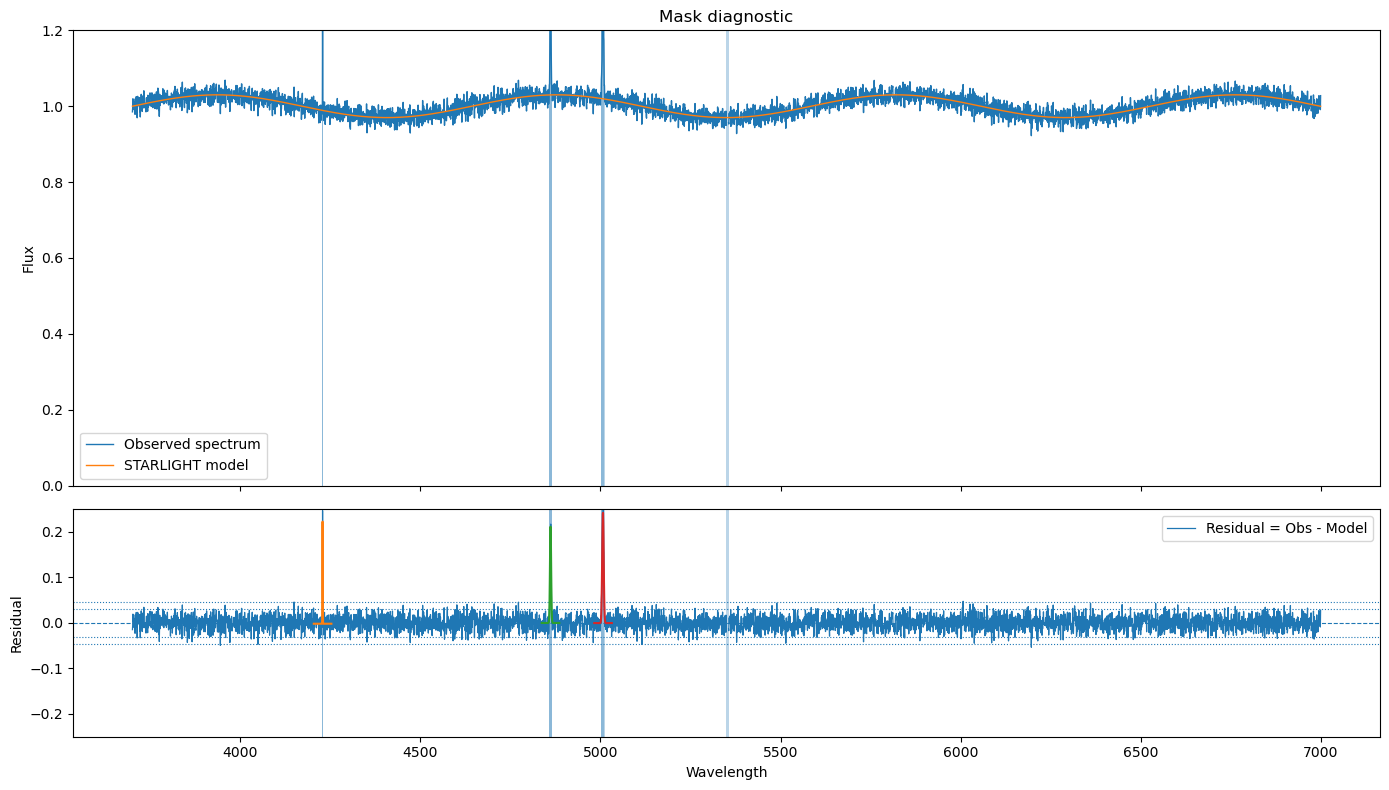

In [27]:
# ============================================================
# Catálogo básico de líneas de emisión ópticas en galaxias HII
# ============================================================
HII_LINE_CATALOG = [
    (3726.032, "[OII]", "3726.032"),
    (3728.815, "[OII]", "3728.815"),
    (3868.760, "[NeIII]", "3868.760"),
    (3889.064, "HeI+H8", "3889.064"),
    (3970.072, "Hepsilon", "3970.072"),
    (4101.734, "Hdelta", "4101.734"),
    (4340.472, "Hgamma", "4340.472"),
    (4363.210, "[OIII]", "4363.210"),
    (4471.480, "HeI", "4471.480"),
    (4685.710, "HeII", "4685.710"),
    (4861.325, "Hbeta", "4861.325"),
    (4958.911, "[OIII]", "4958.911"),
    (5006.843, "[OIII]", "5006.843"),
    (5875.624, "HeI", "5875.624"),
    (6300.304, "[OI]", "6300.304"),
    (6312.060, "[SIII]", "6312.060"),
    (6548.050, "[NII]", "6548.050"),
    (6562.800, "Halpha", "6562.800"),
    (6583.450, "[NII]", "6583.450"),
    (6678.150, "HeI", "6678.150"),
    (6716.440, "[SII]", "6716.440"),
    (6730.820, "[SII]", "6730.820"),
    (7065.190, "HeI", "7065.190"),
    (7135.800, "[ArIII]", "7135.800"),
    (7320.000, "[OII]", "7320 blend"),
    (7330.000, "[OII]", "7330 blend"),
]


# ============================================================
# Utilidades básicas
# ============================================================

def robust_mad_std(x):
    """Estimación robusta de sigma usando MAD."""
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 1.4826 * mad


def gaussian(x, amp, mu, sigma, c):
    """Gaussiana + constante."""
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + c


def contiguous_regions(mask):
    """Convierte una máscara booleana en intervalos contiguos [i0, i1]."""
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return []

    d = np.diff(mask.astype(int))
    starts = np.where(d == 1)[0] + 1
    ends = np.where(d == -1)[0]

    if mask[0]:
        starts = np.r_[0, starts]
    if mask[-1]:
        ends = np.r_[ends, mask.size - 1]

    return list(zip(starts, ends))


def nearest_line_label(mu, tolerance_angstrom=12.0):
    """Asigna una etiqueta física aproximada a una línea ajustada."""
    best = None
    best_dist = np.inf
    for lam0, name, desc in HII_LINE_CATALOG:
        dist = abs(mu - lam0)
        if dist < best_dist:
            best = (lam0, name, desc)
            best_dist = dist

    if best is None or best_dist > tolerance_angstrom:
        return "Unknown", f"gaussian emission candidate @ {mu:.3f} A"

    lam0, name, desc = best
    return name, f"lambda_c={mu:.3f} A ; nearest={lam0:.3f} A"


def merge_record_intervals(records, padding=0.0):
    """
    Fusiona intervalos cercanos sólo si comparten el mismo weight y comentario 1.
    Para comentarios 2 concatena texto único.
    """
    if not records:
        return []

    records = sorted(records, key=lambda r: (r["lambda_min"], r["lambda_max"]))
    merged = [records[0].copy()]

    for rec in records[1:]:
        prev = merged[-1]
        same_class = (
            rec["weight"] == prev["weight"] and
            rec["comment1"] == prev["comment1"]
        )
        close = rec["lambda_min"] <= prev["lambda_max"] + padding

        if same_class and close:
            prev["lambda_max"] = max(prev["lambda_max"], rec["lambda_max"])
            if rec["comment2"] not in prev["comment2"]:
                prev["comment2"] = prev["comment2"] + " | " + rec["comment2"]
        else:
            merged.append(rec.copy())

    return merged


# ============================================================
# Detección de líneas de emisión en el residual
# ============================================================

def fit_emission_line_gaussian(wave, residual, peak_idx,
                               window_angstrom=25.0,
                               min_sigma=0.4,
                               max_sigma=15.0):
    """Ajusta una gaussiana local alrededor de un pico del residual."""
    mu0 = wave[peak_idx]

    sel = (wave >= mu0 - window_angstrom) & (wave <= mu0 + window_angstrom)
    x = wave[sel]
    y = residual[sel]

    if len(x) < 7 or not np.all(np.isfinite(y)):
        return None

    c0 = np.median(y)
    amp0 = residual[peak_idx] - c0
    if amp0 <= 0:
        return None

    dw = np.median(np.diff(wave))
    sigma0 = max(1.5 * dw, 1.0)
    p0 = [amp0, mu0, sigma0, c0]

    bounds = (
        [0.0, mu0 - 3.0, min_sigma, -np.inf],
        [np.inf, mu0 + 3.0, max_sigma, np.inf]
    )

    try:
        popt, pcov = curve_fit(gaussian, x, y, p0=p0, bounds=bounds, maxfev=20000)
        amp, mu, sigma, c = popt
        yfit = gaussian(x, *popt)
        chi_like = np.nanmean((y - yfit) ** 2)

        return {
            "amp": amp,
            "mu": mu,
            "sigma": sigma,
            "continuum": c,
            "chi_like": chi_like,
            "xfit": x,
            "yfit": yfit,
            "window_mask": sel
        }
    except Exception:
        return None


def detect_emission_lines(wave, flux_obs, flux_model,
                          smooth_sigma_pix=1.2,
                          snr_peak=4.0,
                          prominence_sigma=3.0,
                          min_distance_pix=4,
                          fit_window_angstrom=25.0,
                          mask_nsigma=3.0):
    """Detecta líneas de emisión positivas en el residual y las ajusta."""
    residual = flux_obs - flux_model
    residual_smooth = gaussian_filter1d(np.nan_to_num(residual, nan=0.0), smooth_sigma_pix)

    sigma_res = robust_mad_std(residual)
    if not np.isfinite(sigma_res) or sigma_res <= 0:
        raise ValueError("No se pudo estimar el ruido robusto del residual.")

    peaks, props = find_peaks(
        residual_smooth,
        height=snr_peak * sigma_res,
        prominence=prominence_sigma * sigma_res,
        distance=min_distance_pix
    )

    results = []
    records = []

    for p in peaks:
        fit = fit_emission_line_gaussian(
            wave, residual, p,
            window_angstrom=fit_window_angstrom
        )
        if fit is None:
            continue
        if fit["amp"] < snr_peak * sigma_res:
            continue

        lo = fit["mu"] - mask_nsigma * fit["sigma"]
        hi = fit["mu"] + mask_nsigma * fit["sigma"]
        comment1, comment2 = nearest_line_label(fit["mu"])

        fit["comment1"] = comment1
        fit["comment2"] = comment2
        results.append(fit)
        records.append({
            "lambda_min": lo,
            "lambda_max": hi,
            "weight": 0.0,
            "comment1": comment1,
            "comment2": f"emission line ; {comment2} ; sigma={fit['sigma']:.3f} A"
        })

    return {
        "residual": residual,
        "sigma_res": sigma_res,
        "peaks": peaks,
        "fits": results,
        "records": records
    }


# ============================================================
# Detección de spikes / outliers angostos
# ============================================================

def detect_spikes(wave, flux_obs, flux_model,
                  spike_sigma=6.0,
                  max_width_pix=2,
                  grow_pix=1):
    """Detecta spikes positivos o negativos muy angostos en el residual."""
    residual = flux_obs - flux_model
    sigma_res = robust_mad_std(residual)

    if not np.isfinite(sigma_res) or sigma_res <= 0:
        raise ValueError("No se pudo estimar sigma robusto para spikes.")

    bad = np.abs(residual) > spike_sigma * sigma_res
    regions = contiguous_regions(bad)
    records = []

    for i0, i1 in regions:
        width = i1 - i0 + 1
        if width <= max_width_pix:
            j0 = max(0, i0 - grow_pix)
            j1 = min(len(wave) - 1, i1 + grow_pix)
            records.append({
                "lambda_min": float(wave[j0]),
                "lambda_max": float(wave[j1]),
                "weight": 0.0,
                "comment1": "Spike",
                "comment2": f"narrow outlier ; peak residual={np.nanmax(np.abs(residual[i0:i1+1])):.3g}"
            })

    return {
        "sigma_res": sigma_res,
        "records": records
    }


# ============================================================
# Detección de gaps y zonas extremadamente malas (weight=0)
# ============================================================

def detect_gaps_and_hard_bad_regions(wave, flux_obs, flux_model,
                                     hard_sigma=3.0,
                                     min_bad_run_pix=5,
                                     grow_pix=2):
    """
    Detecta:
    - gaps (NaN/inf)
    - regiones persistentemente malas con |residual| > hard_sigma*sigma_res
    """
    residual = flux_obs - flux_model
    sigma_res = robust_mad_std(residual)

    invalid = (
        ~np.isfinite(wave) |
        ~np.isfinite(flux_obs) |
        ~np.isfinite(flux_model)
    )

    hard_bad = np.abs(residual) > hard_sigma * sigma_res
    hard_bad &= np.isfinite(residual)

    regions_invalid = contiguous_regions(invalid)
    regions_bad = contiguous_regions(hard_bad)
    records = []

    for i0, i1 in regions_invalid:
        j0 = max(0, i0 - grow_pix)
        j1 = min(len(wave) - 1, i1 + grow_pix)
        records.append({
            "lambda_min": float(wave[j0]),
            "lambda_max": float(wave[j1]),
            "weight": 0.0,
            "comment1": "Gap",
            "comment2": "NaN/Inf or missing spectral region"
        })

    for i0, i1 in regions_bad:
        width = i1 - i0 + 1
        if width >= min_bad_run_pix:
            j0 = max(0, i0 - grow_pix)
            j1 = min(len(wave) - 1, i1 + grow_pix)
            peak_sig = np.nanmax(np.abs(residual[i0:i1+1])) / sigma_res
            records.append({
                "lambda_min": float(wave[j0]),
                "lambda_max": float(wave[j1]),
                "weight": 0.0,
                "comment1": "BadNoise",
                "comment2": f"hard residual region ; |residual| up to {peak_sig:.2f} sigma"
            })

    return {
        "sigma_res": sigma_res,
        "records": records
    }


# ============================================================
# Detección de ruido moderado (weight=2)
# ============================================================

def detect_soft_bad_regions(wave, flux_obs, flux_model,
                            soft_sigma_low=2.0,
                            soft_sigma_high=3.0,
                            min_run_pix=4,
                            grow_pix=1):
    """
    Detecta zonas con residual moderado: soft_sigma_low <= |residual| < soft_sigma_high.
    Estas regiones reciben weight=2.0.
    """
    residual = flux_obs - flux_model
    sigma_res = robust_mad_std(residual)

    if not np.isfinite(sigma_res) or sigma_res <= 0:
        raise ValueError("No se pudo estimar sigma robusto para ruido moderado.")

    soft = (np.abs(residual) >= soft_sigma_low * sigma_res) & (np.abs(residual) < soft_sigma_high * sigma_res)
    soft &= np.isfinite(residual)

    regions = contiguous_regions(soft)
    records = []

    for i0, i1 in regions:
        width = i1 - i0 + 1
        if width >= min_run_pix:
            j0 = max(0, i0 - grow_pix)
            j1 = min(len(wave) - 1, i1 + grow_pix)
            local_peak = np.nanmax(np.abs(residual[i0:i1+1])) / sigma_res
            records.append({
                "lambda_min": float(wave[j0]),
                "lambda_max": float(wave[j1]),
                "weight": 2.0,
                "comment1": "BadFIT",
                "comment2": f"Trying best fit ; moderate residual region ({soft_sigma_low:.1f}-{soft_sigma_high:.1f} sigma), peak={local_peak:.2f} sigma"
            })

    return {
        "sigma_res": sigma_res,
        "records": records
    }


# ============================================================
# Construcción global de máscara con dos pesos: 0 y 2
# ============================================================

def build_starlight_mask_records(wave, flux_obs, flux_model,
                                 emission_kwargs=None,
                                 spike_kwargs=None,
                                 hard_bad_kwargs=None,
                                 soft_bad_kwargs=None,
                                 merge_padding_angstrom=2.0):
    """
    Construye una máscara final en formato tipo Mask_CRAP:
    - weight=0.0 para líneas, spikes, gaps, ruido inaceptable
    - weight=2.0 para ruido moderado (2-3 sigma por defecto)
    """
    if emission_kwargs is None:
        emission_kwargs = {}
    if spike_kwargs is None:
        spike_kwargs = {}
    if hard_bad_kwargs is None:
        hard_bad_kwargs = {}
    if soft_bad_kwargs is None:
        soft_bad_kwargs = {}

    out_em = detect_emission_lines(wave, flux_obs, flux_model, **emission_kwargs)
    out_sp = detect_spikes(wave, flux_obs, flux_model, **spike_kwargs)
    out_hard = detect_gaps_and_hard_bad_regions(wave, flux_obs, flux_model, **hard_bad_kwargs)
    out_soft = detect_soft_bad_regions(wave, flux_obs, flux_model, **soft_bad_kwargs)

    records_hard = out_em["records"] + out_sp["records"] + out_hard["records"]
    records_hard = merge_record_intervals(records_hard, padding=merge_padding_angstrom)

    # Construimos mapas por pixel: 1=normal, 2=soft, 0=hard
    pixel_class = np.ones(len(wave), dtype=int)

    for rec in out_soft["records"]:
        m = (wave >= rec["lambda_min"]) & (wave <= rec["lambda_max"])
        pixel_class[m] = 2

    for rec in records_hard:
        m = (wave >= rec["lambda_min"]) & (wave <= rec["lambda_max"])
        pixel_class[m] = 0

    # Reconstrucción de regiones weight=2 libres de solapamiento con weight=0
    soft_regions = contiguous_regions(pixel_class == 2)
    soft_records = []
    residual = flux_obs - flux_model
    sigma_res = robust_mad_std(residual)

    for i0, i1 in soft_regions:
        local = residual[i0:i1+1]
        peak_sig = np.nanmax(np.abs(local)) / sigma_res if np.isfinite(sigma_res) and sigma_res > 0 else np.nan
        soft_records.append({
            "lambda_min": float(wave[i0]),
            "lambda_max": float(wave[i1]),
            "weight": 2.0,
            "comment1": "BadFIT",
            "comment2": f"Trying best fit ; moderate residual region, peak={peak_sig:.2f} sigma"
        })

    soft_records = merge_record_intervals(soft_records, padding=merge_padding_angstrom)
    final_records = merge_record_intervals(records_hard + soft_records, padding=merge_padding_angstrom)

    return {
        "records": final_records,
        "pixel_class": pixel_class,
        "residual": residual,
        "sigma_res": sigma_res,
        "emission": out_em,
        "spikes": out_sp,
        "hard_bad": out_hard,
        "soft_bad": out_soft,
    }


# ============================================================
# Escritura del archivo estilo Mask_CRAP.txt
# ============================================================

def save_mask_crap_format(filename, records):
    """
    Guarda archivo con formato:
    Nmask
    lambda_min lambda_max weight comment1 comment2
    """
    with open(filename, "w", encoding="utf-8") as f:
        f.write(f"{len(records)}\n")
        for rec in records:
            f.write(
                f"{rec['lambda_min']:.1f}  {rec['lambda_max']:.1f}  {rec['weight']:.1f}  "
                f"{rec['comment1']:<12s} {rec['comment2']}\n"
            )


# ============================================================
# Visualización
# ============================================================

def plot_mask_diagnostics(wave, flux_obs, flux_model, result,
                          figsize=(14, 8), title=None):
    """
    Muestra:
    1) espectro observado y modelo
    2) residual con regiones weight=0 y weight=2
    3) gaussianas ajustadas a líneas de emisión
    """
    residual = flux_obs - flux_model
    fits = result["emission"]["fits"]
    records = result["records"]

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
    ax0, ax1 = axes

    ax0.plot(wave, flux_obs, lw=1.0, label="Observed spectrum")
    ax0.plot(wave, flux_model, lw=1.0, label="STARLIGHT model")

    for rec in records:
        color_alpha = 0.30 if rec["weight"] == 0.0 else 0.15
        ax0.axvspan(rec["lambda_min"], rec["lambda_max"], alpha=color_alpha)

    ax0.set_ylabel("Flux")
    ax0.set_yscale("linear")
    ax0.set_ylim([0,1.2])
    ax0.legend()
    if title is not None:
        ax0.set_title(title)

    ax1.plot(wave, residual, lw=0.9, label="Residual = Obs - Model")
    ax1.axhline(0.0, ls="--", lw=0.8)
    sig = robust_mad_std(residual)
    if np.isfinite(sig):
        ax1.axhline(2 * sig, ls=":", lw=0.8)
        ax1.axhline(-2 * sig, ls=":", lw=0.8)
        ax1.axhline(3 * sig, ls=":", lw=0.8)
        ax1.axhline(-3 * sig, ls=":", lw=0.8)

    for rec in records:
        color_alpha = 0.30 if rec["weight"] == 0.0 else 0.15
        ax1.axvspan(rec["lambda_min"], rec["lambda_max"], alpha=color_alpha)

    for fit in fits:
        ax1.plot(fit["xfit"], fit["yfit"], lw=1.5)

    ax1.set_xlabel("Wavelength")
    ax1.set_ylabel("Residual")
    ax1.set_ylim([-0.25,0.25])
    ax1.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# Ejemplo mínimo de uso
# ============================================================
if __name__ == "__main__":
    # Ejemplo sintético rápido
    rng = np.random.default_rng(123)
    wave = np.linspace(3700, 7000, 5000)
    flux_model = 1.0 + 0.03 * np.sin((wave - 3700) / 150)
    flux_obs = flux_model.copy()
    flux_obs += 0.20 * np.exp(-0.5 * ((wave - 4861.3) / 1.7) ** 2)
    flux_obs += 0.25 * np.exp(-0.5 * ((wave - 5006.8) / 2.0) ** 2)
    flux_obs += rng.normal(0, 0.015, size=wave.size)
    flux_obs[800] += 0.25
    flux_obs[2500:2508] = np.nan

    result = build_starlight_mask_records(
        wave, flux_obs, flux_model,
        emission_kwargs=dict(snr_peak=4.0, prominence_sigma=3.0, mask_nsigma=3.0),
        spike_kwargs=dict(spike_sigma=6.0, max_width_pix=2, grow_pix=1),
        hard_bad_kwargs=dict(hard_sigma=3.0, min_bad_run_pix=5, grow_pix=2),
        soft_bad_kwargs=dict(soft_sigma_low=2.0, soft_sigma_high=3.0, min_run_pix=4, grow_pix=1),
        merge_padding_angstrom=2.0,
    )

    save_mask_crap_format("Mask_AUTO.txt", result["records"])
    plot_mask_diagnostics(wave, flux_obs, flux_model, result, title="Mask diagnostic")


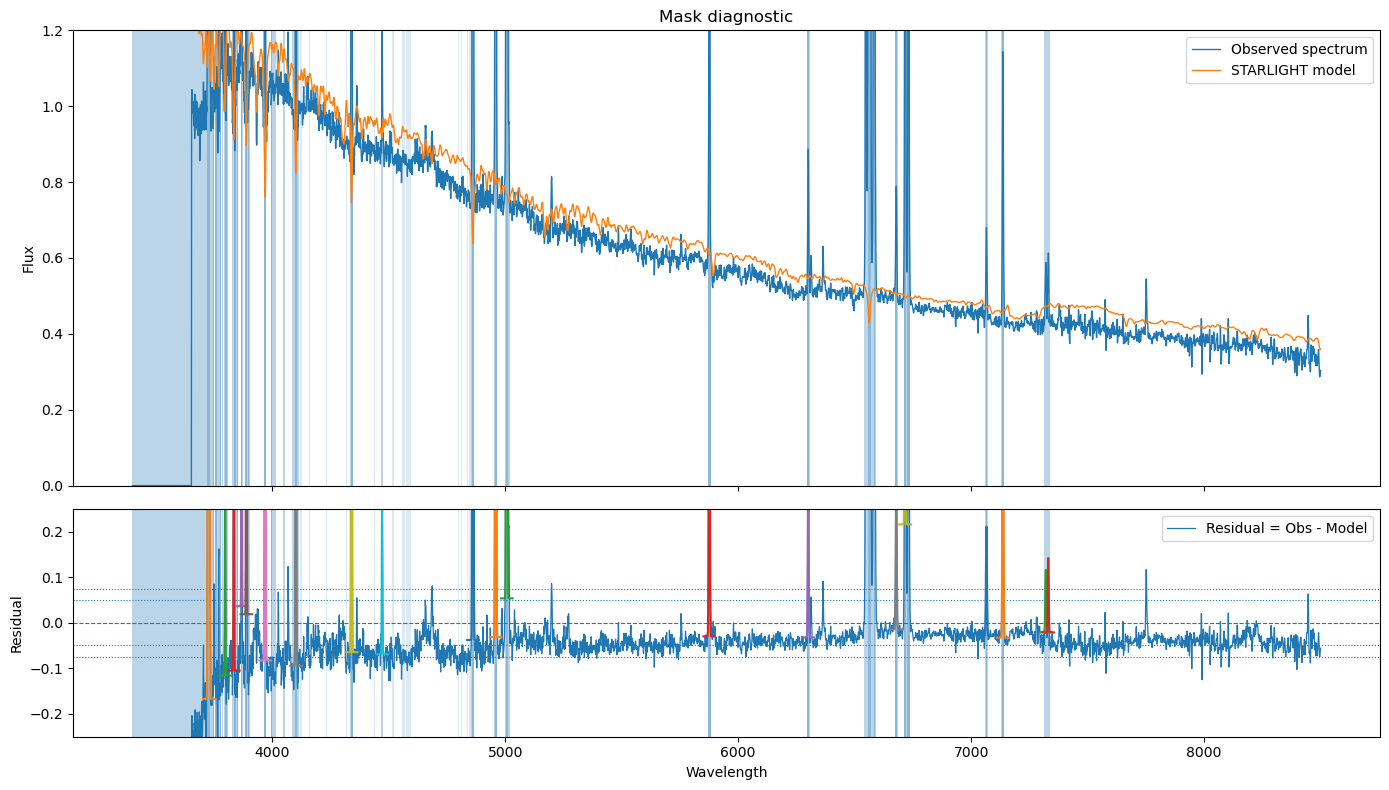

In [33]:
# ============================================================
# Ejemplo de uso
# ============================================================

if __name__ == "__main__":
    # ========================================================
    # EJEMPLO SINTÉTICO
    # Reemplaza esta parte con tus arrays reales:
    # wave, flux_obs, flux_model
    # ========================================================


    name = '/home/holman/StarLightv05/outputs/prefit/' + '077.CAL.MILES45.fits'


    if os.path.exists(name) != True:
        raise FileNotFoundError('File is not in folder. Try relocating the file or changing the name')
    
    FITS = fits.open(name)

    TABLE = Table.read(FITS[2])

    l_obs = TABLE['l_obs']
    f_obs = TABLE['f_obs']
    f_syn = TABLE['f_syn']

    wave = l_obs
    flux_obs = f_obs
    flux_model = f_syn







    result = build_starlight_mask_records(
        wave, flux_obs, flux_model,
        emission_kwargs=dict(snr_peak=4.0, prominence_sigma=3.0, mask_nsigma=3.0),
        spike_kwargs=dict(spike_sigma=6.0, max_width_pix=2, grow_pix=1),
        hard_bad_kwargs=dict(hard_sigma=4.0, min_bad_run_pix=5, grow_pix=2),
        soft_bad_kwargs=dict(soft_sigma_low=3.0, soft_sigma_high=4.0, min_run_pix=4, grow_pix=1),
        merge_padding_angstrom=2.0,
    )

    save_mask_crap_format("Mask_AUTO.txt", result["records"])
    plot_mask_diagnostics(wave, flux_obs, flux_model, result, title="Mask diagnostic")